# Extended Data Figure 3 — Temporal trends in gene-measurement associations

Cumulative unique measurement-associated genes discovered per year,
stratified by:

- NFE common (MAF ≥ 0.01, European ancestry)
- All common (MAF ≥ 0.01, any ancestry)
- All (including rare variants, MAF < 0.01)

**Source notebook:** `chapters/02-analysis/01-descriptions-numbers/02_gene_stauration_plots.ipynb`  
**Data:** `data/intermediate_files/list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet`,
`data/intermediate_files/qualifying_measurement_credible_sets/`


## Setup


In [1]:
from gentropy.common.session import Session
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/15 16:02:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/15 16:02:21 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Paths


In [3]:
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

l2g_with_year_path = path_to_intermediate_data_folder + "list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet"
qualifying_measurement_cs_path = path_to_intermediate_data_folder + "qualifying_measurement_credible_sets"
qualifying_disease_cs_path = path_to_intermediate_data_folder + "qualifying_credible_sets"


## Load L2G gene-disease/measurement associations with year and ancestry flags


In [4]:
l2g_full = session.spark.read.parquet(l2g_with_year_path)

# Qualifying measurement credible sets filter
qm_cs = session.spark.read.parquet(qualifying_measurement_cs_path).select("studyLocusId").cache()
print(f"Qualifying measurement CSs: {qm_cs.count():,}")


Qualifying measurement CSs: 450,357


In [5]:
# Filter l2g to qualifying measurement CSs and convert to pandas
l2g_measurements_full = l2g_full.join(qm_cs, on="studyLocusId", how="inner").toPandas()
print(f"Gene-measurement associations: {len(l2g_measurements_full):,}")
l2g_measurements_full.head(2)


Gene-measurement associations: 453,009


,studyLocusId,studyId,geneId,score,eQTL_coloc,pQTL_coloc,VEP,distanceTSS,maf,variantId,absBeta,year,is_nfe,diseaseIds,nfe_common,non_nfe_common,rare
0,0002cd1632205979d9155eaf192c868c,GCST004567,ENSG00000112715,0.351263,0,0,0,1,0.480536,6_43790159_C_A,0.033645,2017,1,"[EFO_0007788, EFO_0008002]",1,0,0
1,0003696a50893286fa2b9eaaf753b054,GCST90302030,ENSG00000103569,0.626518,0,0,0,1,0.001632,15_58207366_G_T,0.450297,2024,0,[EFO_0020947],0,0,1


## Extended Data Figure 3

Two-panel stacked bar chart:

- **Top panel:** cumulative unique measurement-associated genes per year
- **Bottom panel:** cumulative unique gene–measurement pairs (geneId × studyId) per year

Both panels stratified by variant frequency and ancestry tier:

- NFE common: MAF ≥ 0.01, studies ≥ 90% non-Finnish European
- Non-NFE common: MAF ≥ 0.01, other ancestries
- Rare: MAF < 0.01

Bars show the additive "discovery reach" at each inclusiveness threshold.


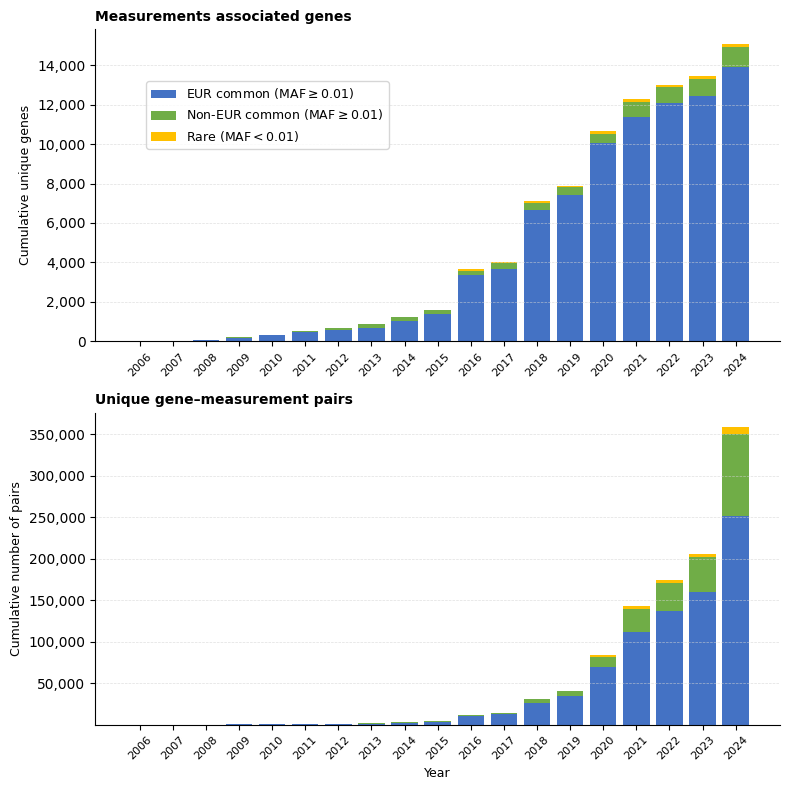

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


def get_cumulative_by_tier(df, mask, id_cols, year_col="year"):
    """First year each unique ID (gene or pair) appears under the given mask."""
    sub = df[mask][id_cols + [year_col]].drop_duplicates()
    sub = sub[sub[year_col] != 2025]
    first = sub.groupby(id_cols)[year_col].min().reset_index()
    per_year = first.groupby(year_col).size().rename("count").reset_index()
    per_year["cumulative"] = per_year["count"].cumsum()
    return per_year.set_index(year_col)["cumulative"]


def make_stacked_bar_panel(ax, df, id_cols, ylabel):
    """Stacked bar chart: EUR common / non-EUR common / Rare (additive tiers)."""
    mask_eur = df["nfe_common"] == 1
    mask_all_common = (df["nfe_common"] == 1) | (df["non_nfe_common"] == 1)
    mask_all = df["nfe_common"].notnull()

    cum_eur = get_cumulative_by_tier(df, mask_eur, id_cols)
    cum_all_common = get_cumulative_by_tier(df, mask_all_common, id_cols)
    cum_all = get_cumulative_by_tier(df, mask_all, id_cols)

    years = sorted(set(cum_eur.index) | set(cum_all_common.index) | set(cum_all.index))
    dp = pd.DataFrame(index=years)
    dp["eur"] = cum_eur.reindex(years).ffill().fillna(0).astype(int)
    dp["all_common"] = cum_all_common.reindex(years).ffill().fillna(0).astype(int)
    dp["all"] = cum_all.reindex(years).ffill().fillna(0).astype(int)
    dp["non_eur"] = dp["all_common"] - dp["eur"]
    dp["rare"] = dp["all"] - dp["all_common"]

    x = [str(y) for y in dp.index]
    ax.bar(x, dp["eur"], color="#4472C4", label=r"EUR common (MAF$\geq$0.01)")
    ax.bar(x, dp["non_eur"], color="#70AD47", bottom=dp["eur"], label=r"Non-EUR common (MAF$\geq$0.01)")
    ax.bar(x, dp["rare"], color="#FFC000", bottom=dp["eur"] + dp["non_eur"], label=r"Rare (MAF$<$0.01)")

    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

make_stacked_bar_panel(ax1, l2g_measurements_full, id_cols=["geneId"], ylabel="Cumulative unique genes")
ax1.set_title("Measurements associated genes", fontsize=10, fontweight="bold", loc="left")
ax1.set_xlabel("")

make_stacked_bar_panel(ax2, l2g_measurements_full, id_cols=["geneId", "studyId"], ylabel="Cumulative number of pairs")
ax2.set_title("Unique gene–measurement pairs", fontsize=10, fontweight="bold", loc="left")
ax2.set_xlabel("Year", fontsize=9)

# Legend above both panels, horizontal
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.9), ncols=1)

fig.tight_layout()
fig.savefig("extended_figure_3.pdf", dpi=300, bbox_inches="tight")
plt.show()
